## Rating Prediction - Model Comparison
**Similarity Based:** 
- Item-based KNN basic
- Item-based KNN with mean
- Co-cluster model 

**Model Based:** 
- Matrix factorization SVD model

*No user-based model attempted as there are more unknown users but only 1 unknown item*

In [1]:
#pip install surprise

In [12]:
# import library
import numpy as np
import pandas as pd
import os
import json
import ast
from datetime import datetime
from surprise import accuracy, Reader,Dataset, SVD, SVDpp, KNNBasic, CoClustering,KNNWithMeans
from surprise.model_selection import cross_validate
from surprise.model_selection import train_test_split
from surprise.model_selection import split
from sklearn.metrics import mean_squared_error

In [2]:
# import data
with open('train.json') as f:
    raw=[ast.literal_eval(l) for l in f.readlines()]
df = pd.DataFrame(raw)

#df=df.sort_values(ascending=True,by=['unixReviewTime'])
df2 = df[['reviewerID','itemID', 'rating']]

In [4]:
# prepare the data to user Surprise libary
# https://surprise.readthedocs.io/en/stable/matrix_factorization.html  
# KNN Basic, KNN with mean, CoClustering, SVD 
reader = Reader(rating_scale=(1,5))
data=Dataset.load_from_df(df2[["reviewerID", "itemID", "rating"]], reader)

In [5]:
# using 10 fold data for training
train,holdout = train_test_split(data, test_size=0.2 )
kSplit = split.KFold(n_splits=10, shuffle=True)

In [13]:
# initilaize rmse for comparison
rmseKNNBasicItem = []
rmseKNNWithMeanItem = []
rmseSVD = []
rmseCo=[]

In [15]:
# Basic KNN model - item based
sim_options = sim_options = {'name': 'cosine','user_based': False}
KnnBasicItem = KNNBasic(k=40,sim_options=sim_options) 

for trainset, testset in kSplit.split(data): 
    KnnBasicItem.fit(trainset)
    predictionsKNN = KnnBasicItem.test(testset)
    rmseKNNBasicItem.append(accuracy.rmse(predictionsKNN,verbose=True))

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1379
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1523
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1365
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1380
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1314
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1369
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1437
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1361
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1422
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1408


In [14]:
# KNN With Mean model - model based
sim_options = sim_options = {'name': 'cosine','user_based': False}
KnnWithMeanItem = KNNWithMeans(k=40,sim_options=sim_options) 

for trainset, testset in kSplit.split(data): 
    KnnWithMeanItem.fit(trainset)
    predictionsKNN = KnnWithMeanItem.test(testset)
    rmseKNNWithMeanItem.append(accuracy.rmse(predictionsKNN,verbose=True))

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1630
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1649
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1609
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1718
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1518
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1576
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1580
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1445
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1514
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1446


In [16]:
# SVD model 
svd = SVD(n_factors=1, biased=True, n_epochs=20,random_state=15, 
         lr_all=0.005, reg_all=0.05)

min_error = 1
for trainset, testset in kSplit.split(data): 
    svd.fit(trainset)
    predictionsSVD = svd.test(testset)
    rmseSVD.append(accuracy.rmse(predictionsSVD,verbose=True))

RMSE: 1.0499
RMSE: 1.0448
RMSE: 1.0586
RMSE: 1.0569
RMSE: 1.0446
RMSE: 1.0517
RMSE: 1.0585
RMSE: 1.0597
RMSE: 1.0470
RMSE: 1.0436


In [17]:
# Co cluster model
rmseCo=[]
coClus = CoClustering(n_cltr_u=4,n_cltr_i=4,n_epochs=25) 
for trainset, testset in kSplit.split(data): 
    coClus.fit(trainset)
    predictionsCoClus = coClus.test(testset)
    rmseCo.append(accuracy.rmse(predictionsCoClus,verbose=True))

RMSE: 1.2065
RMSE: 1.1872
RMSE: 1.1964
RMSE: 1.2191
RMSE: 1.1870
RMSE: 1.1905
RMSE: 1.1802
RMSE: 1.2123
RMSE: 1.2037
RMSE: 1.1951


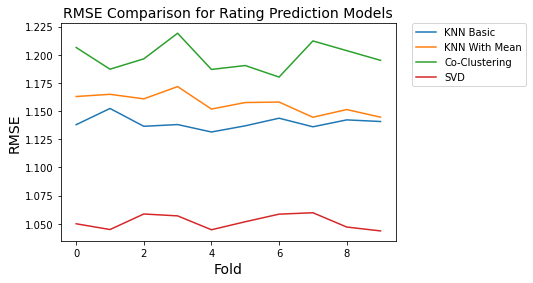

In [18]:
## plot each model's MSE for comparison
import matplotlib.pyplot as plt

modelPrediction = plt.plot(rmseKNNBasicItem,label='KNN Basic')
modelPrediction = plt.plot(rmseKNNWithMeanItem,label='KNN With Mean')
modelPrediction = plt.plot(rmseCo,label='Co-Clustering')
modelPrediction = plt.plot(rmseSVD,label='SVD')
modelPrediction = plt.xlabel('Fold', fontsize=14)
modelPrediction = plt.ylabel('RMSE', fontsize=14)
plt.title('RMSE Comparison for Rating Prediction Models', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

SVD outperformed other models as expected.
Final model & further performance tuning will focus on SVD model